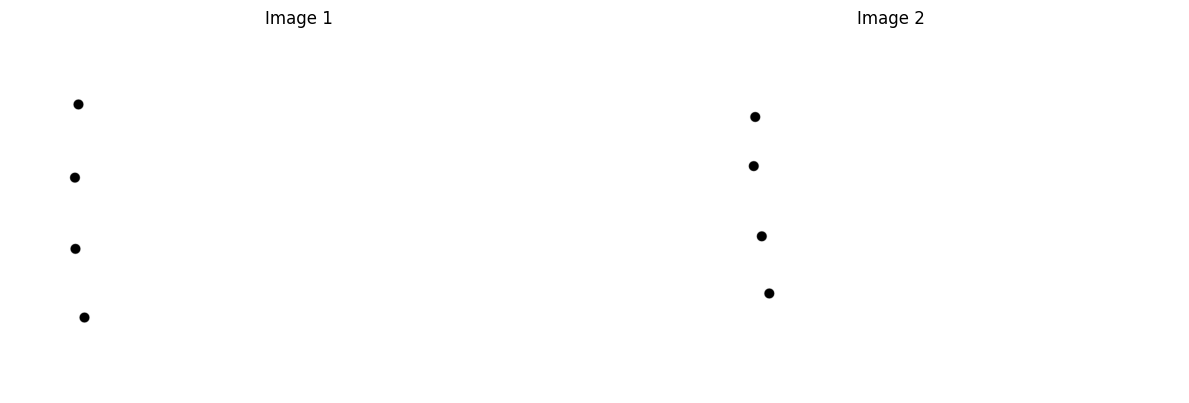

In [ ]:

from cellmech.imgproc.bead_detection import denoise_image, cluster_beads, bead_image_correlation, get_fidelity
from cellmech import plot_vector_field
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt

def plot_side_by_side(img1: np.ndarray, img2: np.ndarray, title1="Image 1", title2="Image 2"):
    """
    Plots two ndarrays side by side using Matplotlib.
    """
    # Create a figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot first image
    # cmap='gray' is essential if your 0/1 array is 2D
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off') # Hide x and y ticks for a cleaner look

    # Plot second image
    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')

    plt.tight_layout() # Adjusts spacing so titles don't overlap
    plt.show()

# Example usage with your bead arrays:
# plot_side_by_side(ref_binary, def_binary, "Reference Beads", "Deformed Beads")

# img1 = np.array(Image.open('../images/beads/img2/before.png').convert('L'))
# img2 = np.array(Image.open('../images/beads/img2/after.png').convert('L'))

image_path = "img_test1"
img1 = np.array(Image.open(f'../images/beads/{image_path}/before.png').convert('L'))
img2 = np.array(Image.open(f'../images/beads/{image_path}/after.png').convert('L'))


img1 = denoise_image(img1)
img2 = denoise_image(img2)

plot_side_by_side(img1, img2)

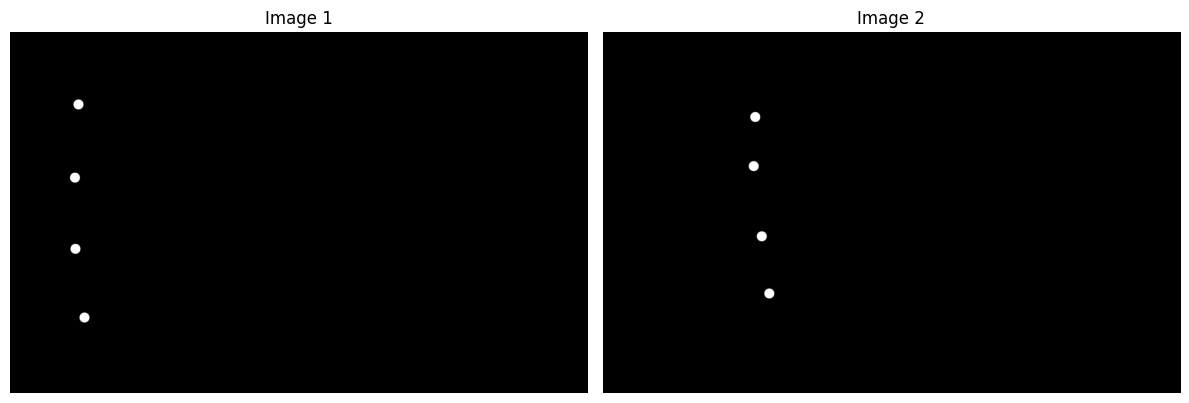

In [2]:
grey1, beads1 = cluster_beads(img1)
grey2, beads2 = cluster_beads(img2)
# print("fidelity : ", get_fidelity(img1/np.max(img1), img2/np.max(img2), beads1, beads2))
# plot_side_by_side(beads1, beads2)
plot_side_by_side(grey1, grey2)



pushhen  [136. 144.]
pushhen  [129. 291.]
pushhen  [130. 432.]
pushhen  [148. 569.]


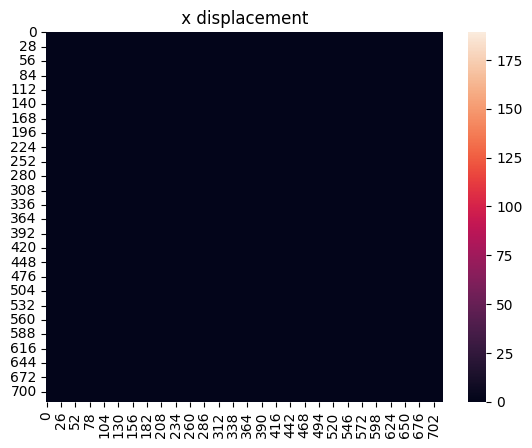

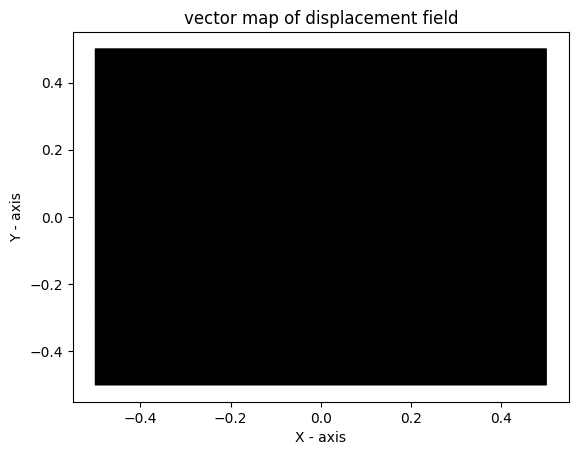

In [3]:
displfield = bead_image_correlation(grey1, grey2)
fig = plot_vector_field(displfield/100, "vector map of displacement field")